# Classic Methods

# Data

In [7]:
## Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
import tabulate
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import seaborn as sns
import tensorflow as tf
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn

In [8]:
## Import Dataset
df = pd.read_csv("data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
## Basic Train/Test/Validation Split / Saled Data / SMOTE Data / PYtorch data

## Train/Test
x_train, x_test, y_train, y_test = train_test_split(df.drop("Class", axis=1), df["Class"], test_size=0.2, random_state=42)

## Train/Val
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.2, random_state=42)

## Scaled version
scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

## SMOTE Dataset
sm = SMOTE(random_state=42)
x_train_sm, y_train_sm = sm.fit_resample(x_train_scaled, y_train)

## Pytorch Dataset for Pytorch deep neural net
x_test_scaled_pt = torch.tensor(x_test_scaled, dtype=torch.float32)
y_test_pt = torch.tensor(y_test, dtype=torch.float32)
x_val_scaled_pt = torch.tensor(x_val_scaled, dtype=torch.float32)
y_val_pt = torch.tensor(y_val.values, dtype=torch.float32)
x_train_scaled_pt = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_pt = torch.tensor(y_train.values, dtype=torch.float32)

# EDA

In [ ]:
## Colnames
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

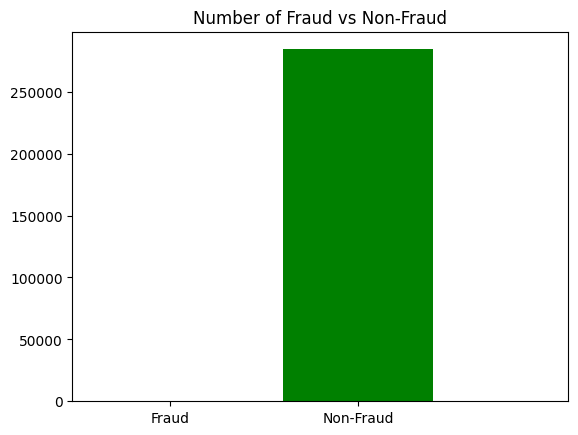

Non-Fraud: 284315
Fraud: 492


In [ ]:
## Number of Fraud vs Non-Fraud
plt.plot(2, 10)
plt.title("Number of Fraud vs Non-Fraud")
plt.bar(["Fraud", "Non-Fraud"], [df["Class"].value_counts()[1], df["Class"].value_counts()[0]], color = ["red", "green"])
plt.show()

## Counts (Highly Imbalanced)
print("Non-Fraud:", df["Class"].value_counts()[0])
print("Fraud:", df["Class"].value_counts()[1])

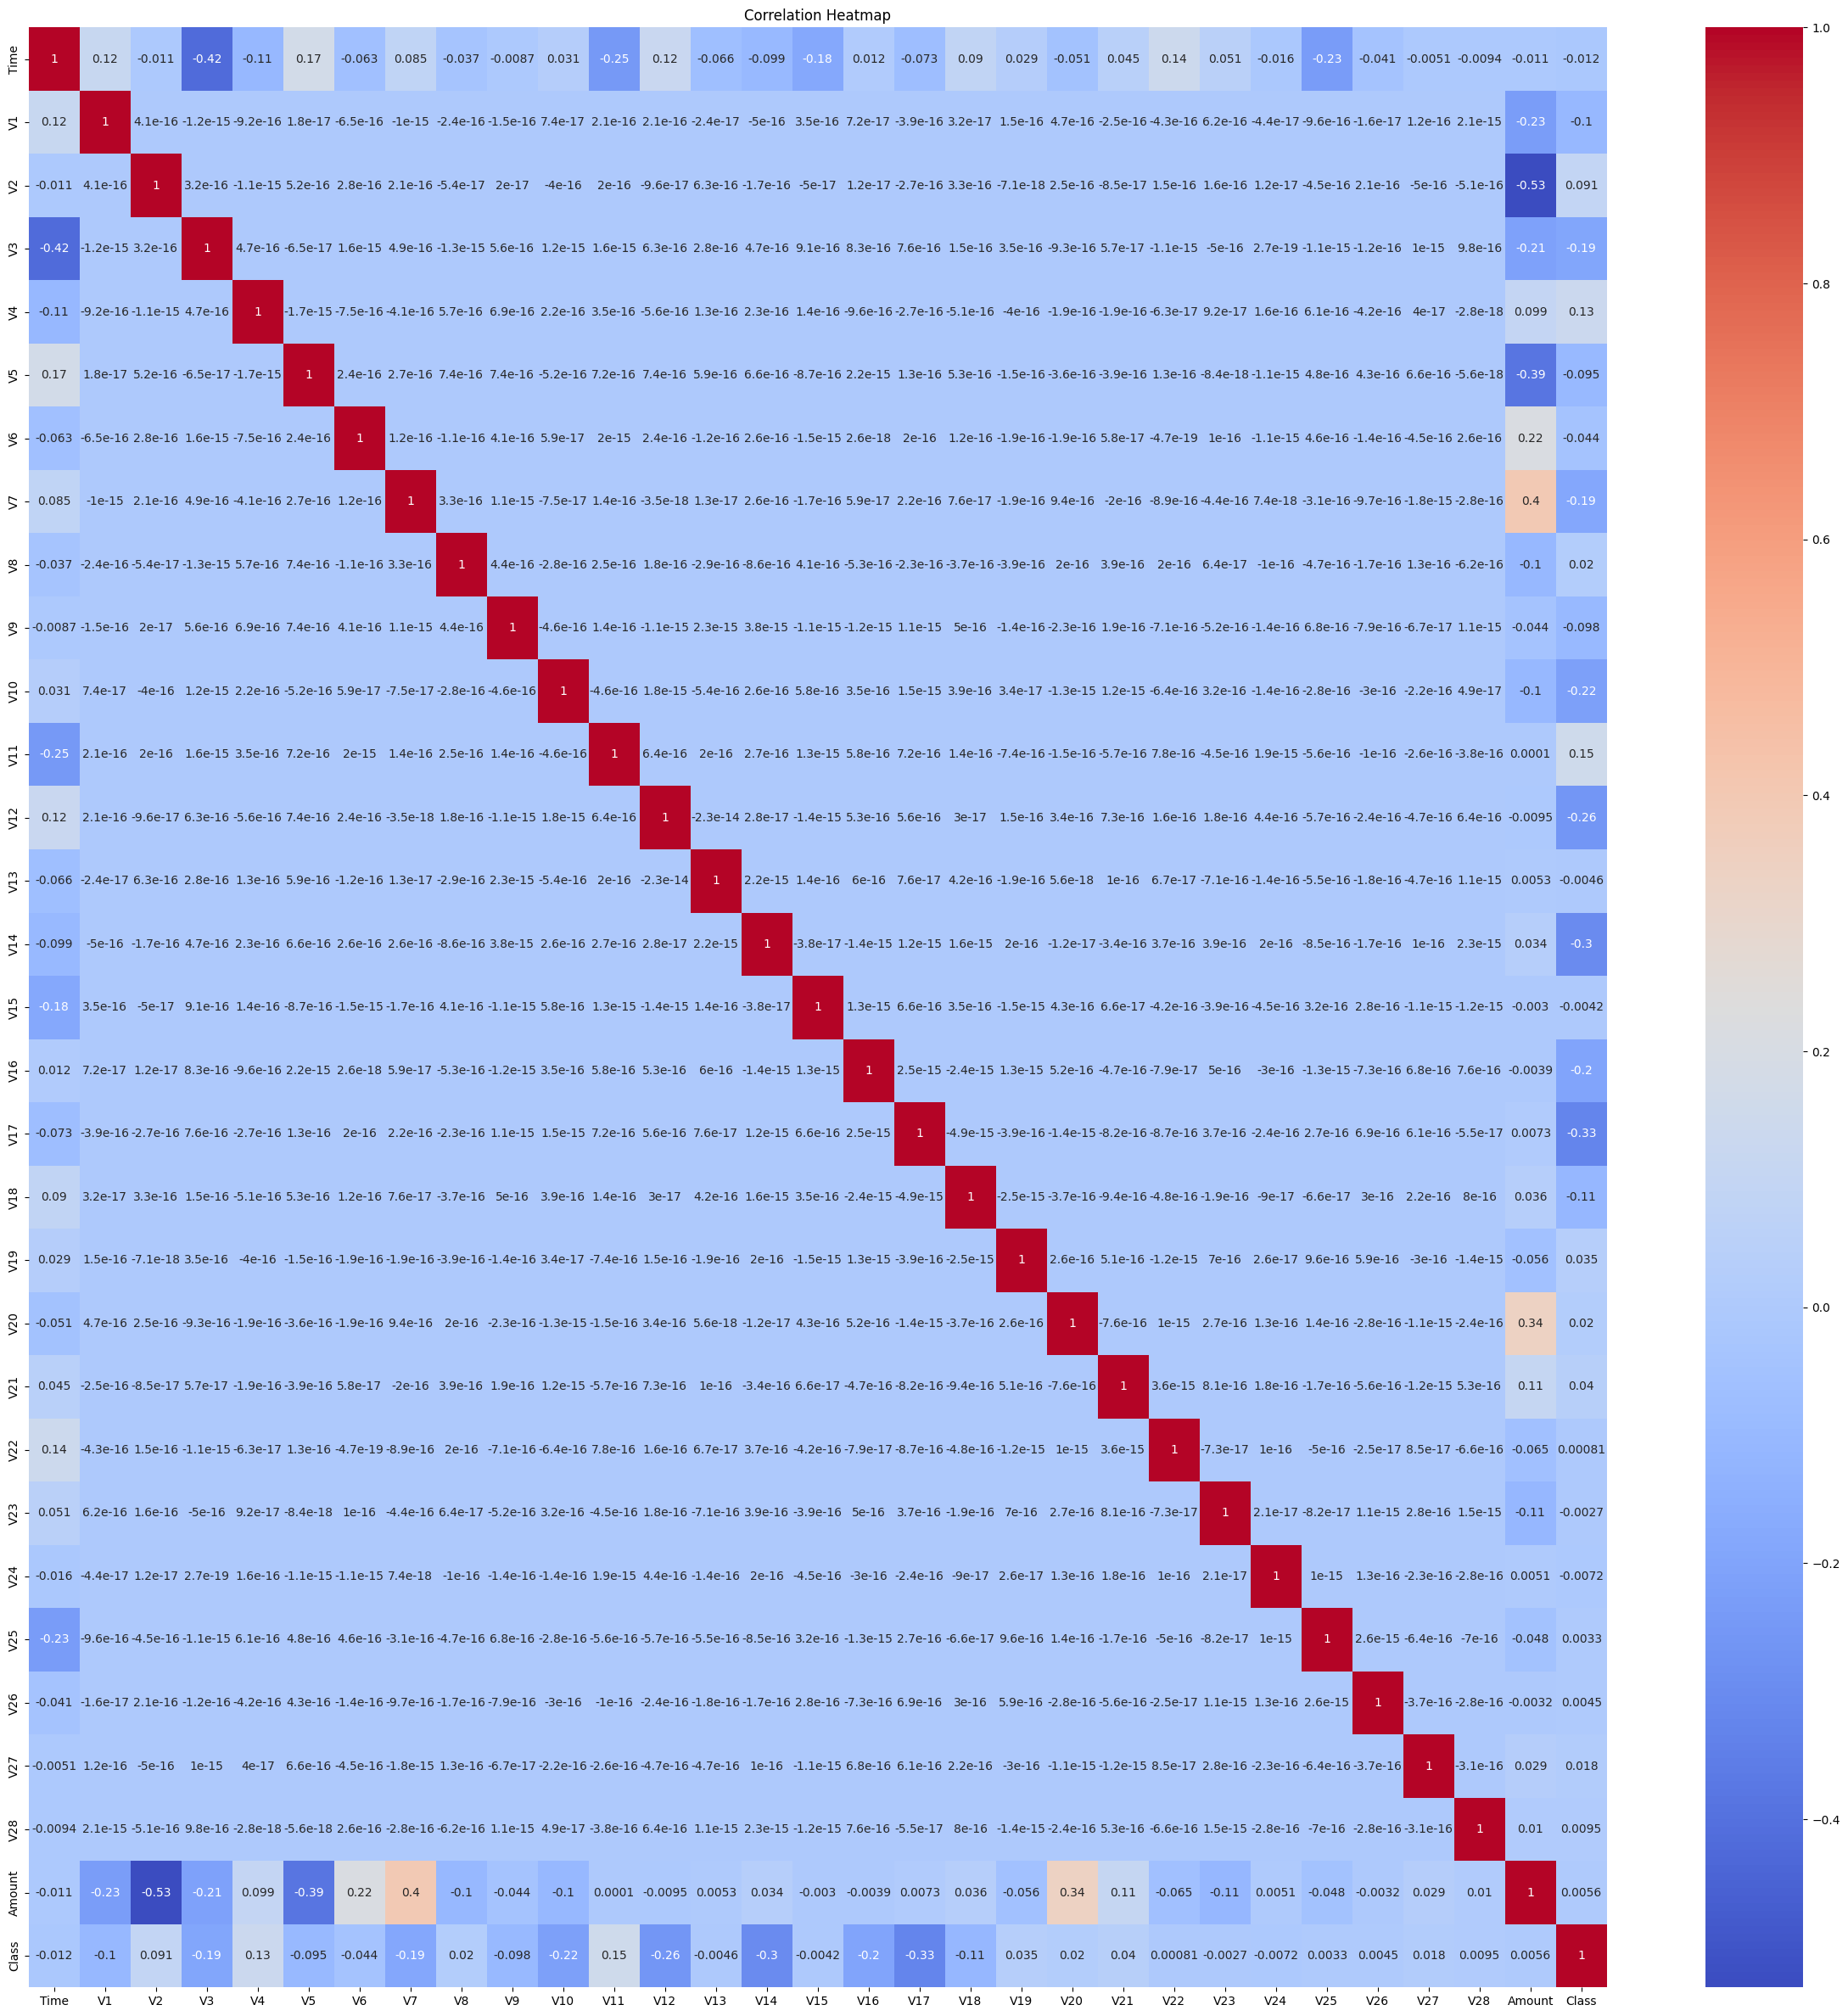

In [ ]:
## Correlation Heatmap of Features
plt.figure(figsize=(30, 30))
sns.heatmap(df.corr(), cmap="coolwarm", annot = True)
plt.title("Correlation Heatmap")
plt.show()



# Model Training and Tuning

In [ ]:
## Scoring Function Using Validation Set for Tuning (Accuracy, Precision, Recall, F1, Brier)
def Scoring_Function(y_pred):
  tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
  accuracy = (tp+tn)/(tp+tn+fp+fn)
  precision = tp/(tp+fp) if (tp+fp) != 0 else 0
  recall = tp/(tp+fn) if (tp+fn)!= 0 else  0
  f1 = 2*precision*recall/(precision+recall) if (precision+recall) != 0 else 0
  brier = np.mean((y_val - y_pred)**2)
  tab = [["Accuracy", accuracy], ["Precision", precision], ["Recall", recall], ["F1", f1], ["Brier Score", brier]]
  return(tabulate.tabulate(tab, headers=["Scoring Metric", "Value"]))

In [ ]:
## Scoring Function Using Test Set for Final Evaluation
def Scoring_Function_Test(y_pred):
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
  accuracy = (tp+tn)/(tp+tn+fp+fn)
  precision = tp/(tp+fp) if (tp+fp) != 0 else 0
  recall = tp/(tp+fn) if (tp+fn)!= 0 else  0
  f1 = 2*precision*recall/(precision+recall) if (precision+recall) != 0 else 0
  brier = np.mean((y_test - y_pred)**2)
  tab = [["Accuracy", accuracy], ["Precision", precision], ["Recall", recall], ["F1", f1], ["Brier Score", brier]]
  return accuracy, precision, recall, f1, brier

Best Threshold: 0.01
Scoring Metric          Value
----------------  -----------
Accuracy          0.999561
Precision         0.907407
Recall            0.765625
F1                0.830508
Brier Score       0.000438895


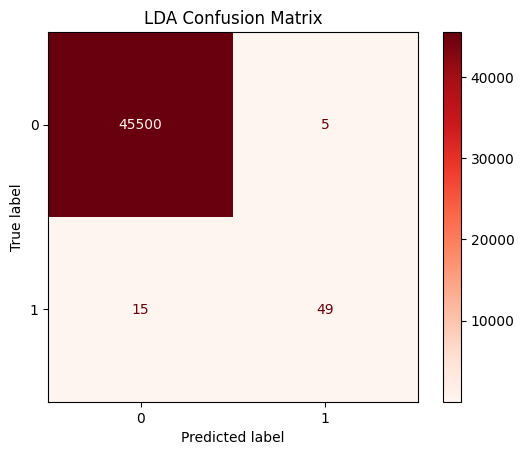

In [ ]:
## LDA

## Fit
lda = LinearDiscriminantAnalysis()
lda.fit(x_train, y_train)

## Tune Decision Boundry (F1)
decision_thresholds = np.linspace(0, 1, 100)
f1_scores = []
for threshold in decision_thresholds:
  y_pred_lda = lda.predict_proba(x_val)[:, 1] > threshold
  f1_scores.append(f1_score(y_val, y_pred_lda))
best_threshold = decision_thresholds[np.argmax(f1_scores)]
y_pred_lda = lda.predict_proba(x_val)[:, 1] > best_threshold

## Test Score (Saved for later final evaluation)
y_pred_lda_test = lda.predict_proba(x_test)[:, 1] > best_threshold

## Score
print(f"Best Threshold: {best_threshold:.2f}")
print(Scoring_Function(y_pred_lda))

## Plots
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_lda, cmap="Reds")
plt.title("LDA Confusion Matrix")
plt.show()

Best Threshold: 0.99
Scoring Metric        Value
----------------  ---------
Accuracy          0.98398
Precision         0.0708763
Recall            0.859375
F1                0.130952
Brier Score       0.0160197


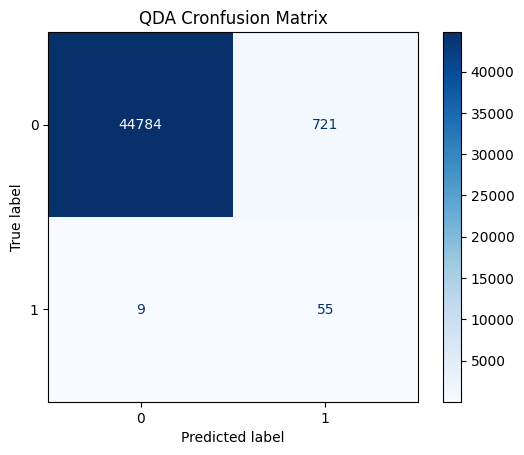

In [ ]:
## QDA

## Fit
qda = QuadraticDiscriminantAnalysis()
qda.fit(x_train, y_train)

## Tune Decision Boundry (F1)
decision_thresholds = np.linspace(0, 1, 100)
f1_scores = []
for threshold in decision_thresholds:
  y_pred_qda = qda.predict_proba(x_val)[:, 1] > threshold
  f1_scores.append(f1_score(y_val, y_pred_qda))
best_threshold = decision_thresholds[np.argmax(f1_scores)]
y_pred_qda = qda.predict_proba(x_val)[:, 1] > best_threshold

## Test Score (Saved for later final evaluation)
y_pred_qda_test = qda.predict_proba(x_test)[:, 1] > best_threshold

## Score
print(f"Best Threshold: {best_threshold:.2f}")
print(Scoring_Function(y_pred_qda))

## Plots
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_qda, cmap="Blues")
plt.title("QDA Cronfusion Matrix")
plt.show()


Best Threshold: 0.99
Scoring Metric         Value
----------------  ----------
Accuracy          0.998947
Precision         0.585106
Recall            0.859375
F1                0.696203
Brier Score       0.00105335


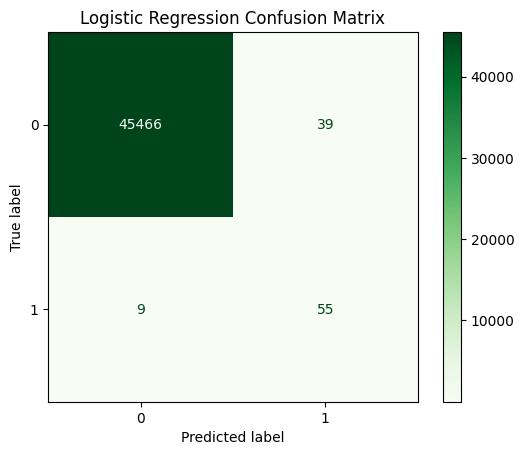

In [ ]:
## Logistic Regression

## Fit
lr = LogisticRegression(class_weight = "balanced", max_iter = 2000, solver = "lbfgs")
lr.fit(x_train_scaled, y_train)

## Tune Decision Boundry
decision_thresholds = np.linspace(0, 1, 100)
f1_scores = []
for threshold in decision_thresholds:
  y_pred_lr = lr.predict_proba(x_val_scaled)[:, 1] > threshold
  f1_scores.append(f1_score(y_val, y_pred_lr))
best_threshold = decision_thresholds[np.argmax(f1_scores)]
y_pred_lr = lr.predict_proba(x_val_scaled)[:, 1] > best_threshold

## Test Score (Saved for later final evaluation)
y_pred_lr_test = lr.predict_proba(x_test_scaled)[:, 1] > best_threshold

## Score
print(f"Best Threshold: {best_threshold:.2f}")
print(Scoring_Function(y_pred_lr))

## Plots
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_lr, cmap="Greens")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


Scoring Metric          Value
----------------  -----------
Accuracy          0.999627
Precision         0.943396
Recall            0.78125
F1                0.854701
Brier Score       0.000373061


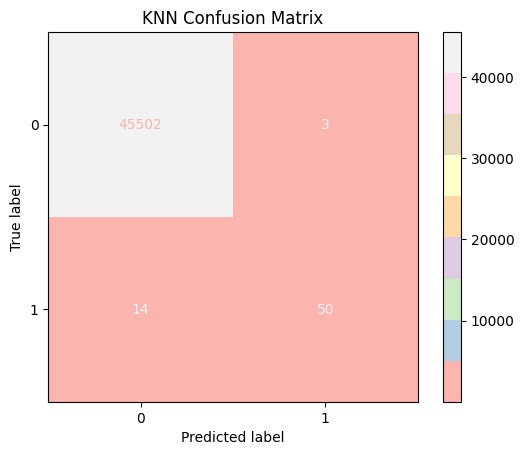

In [ ]:
## KNN

## Fit
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)
knn.fit(x_train_scaled, y_train)
y_pred_knn = knn.predict(x_val_scaled)

## Test Score (Saved for later final evaluation)
y_pred_knn_test = knn.predict(x_test_scaled)

## Score
print(Scoring_Function(y_pred_knn))

## Plots
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_knn, cmap="Pastel1")
plt.title("KNN Confusion Matrix")
plt.show()

Best Threshold: 0.19
Scoring Metric          Value
----------------  -----------
Accuracy          0.999737
Precision         0.948276
Recall            0.859375
F1                0.901639
Brier Score       0.000263337


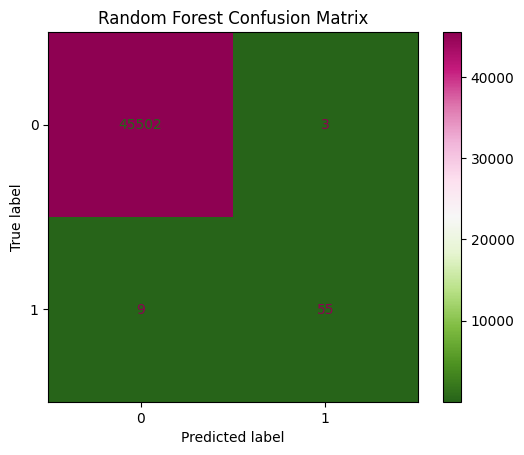

In [ ]:
## Random Forest

## Fit
rf = RandomForestClassifier(class_weight = "balanced")
rf.fit(x_train, y_train)

## Tune Decision Boundry (F1)
decision_thresholds = np.linspace(0, 1, 100)
f1_scores = []
for threshold in decision_thresholds:
  y_pred_rf = rf.predict_proba(x_val)[:, 1] > threshold
  f1_scores.append(f1_score(y_val, y_pred_rf))
best_threshold = decision_thresholds[np.argmax(f1_scores)]
y_pred_rf = rf.predict_proba(x_val)[:, 1] > best_threshold

## Test Score (Saved for later final evaluation)
y_pred_rf_test = rf.predict_proba(x_test)[:, 1] > best_threshold

## Score
print(f"Best Threshold: {best_threshold:.2f}")
print(Scoring_Function(y_pred_rf))

## Plots
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_rf, cmap="PiYG_r")
plt.title("Random Forest Confusion Matrix")
plt.show()

Best Threshold: 0.16
Scoring Metric         Value
----------------  ----------
Accuracy          0.998881
Precision         0.666667
Recall            0.40625
F1                0.504854
Brier Score       0.00111918


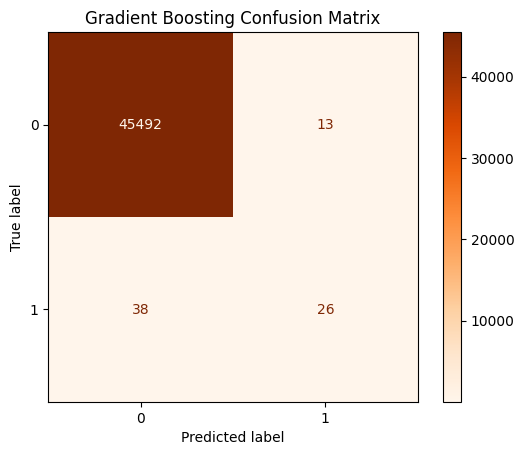

In [ ]:
## Gradient Boosting

## Fit
gb = GradientBoostingClassifier()
gb.fit(x_train, y_train)
y_pred_gb = gb.predict(x_val)

## Tune Decision Boundry (F1)
decision_thresholds = np.linspace(0, 1, 100)
f1_scores = []
for threshold in decision_thresholds:
  y_pred_gb = gb.predict_proba(x_val)[:, 1] > threshold
  f1_scores.append(f1_score(y_val, y_pred_gb))
best_threshold = decision_thresholds[np.argmax(f1_scores)]
y_pred_gb = gb.predict_proba(x_val)[:, 1] > best_threshold

## Test Score (Saved for later final evaluation)
y_pred_gb_test = gb.predict_proba(x_test)[:, 1] > best_threshold

## Score
print(f"Best Threshold: {best_threshold:.2f}")
print(Scoring_Function(y_pred_gb))

## Plots
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_gb, cmap="Oranges")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

Best Threshold: 0.59
Scoring Metric          Value
----------------  -----------
Accuracy          0.999605
Precision         0.870968
Recall            0.84375
F1                0.857143
Brier Score       0.000395005


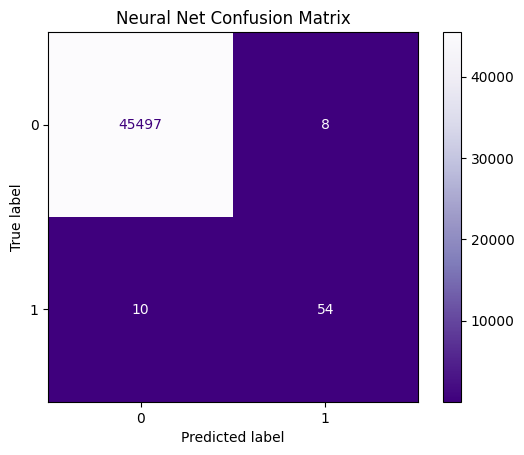

In [ ]:
## Nueral Net

## Fit
net = MLPClassifier(solver = "adam", alpha = .001, hidden_layer_sizes = (5, 2), random_state = 42)
net.fit(x_train_scaled, y_train)
y_pred_net = net.predict(x_val_scaled)

## Tune Decision Boundry (F1)
decision_thresholds = np.linspace(0, 1, 100)
f1_scores = []
for threshold in decision_thresholds:
  y_pred_net = net.predict_proba(x_val_scaled)[:, 1] > threshold
  f1_scores.append(f1_score(y_val, y_pred_net))
best_threshold = decision_thresholds[np.argmax(f1_scores)]
y_pred_net = net.predict_proba(x_val_scaled)[:, 1] > best_threshold

## Test Score (Saved for later final evaluation)
y_pred_net_test = net.predict_proba(x_test_scaled)[:, 1] > best_threshold

## Score
print(f"Best Threshold: {best_threshold:.2f}")
print(Scoring_Function(y_pred_net))

## Plots
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_net, cmap="Purples_r")
plt.title("Neural Net Confusion Matrix")
plt.show()


In [ ]:
## PyTorch Deep Learning Neural Network

## Basic Net Architecture (To be tuned later)
class neural_network(nn.Module):
    def __init__(self, x, y):
      super(neural_network, self).__init__()
      self.model = nn.Sequential(
          nn.Linear(x, 64),nn.ReLU(),
          nn.Linear(64, 32),nn.ReLU(),
          nn.Linear(32, 16),nn.ReLU(),
          nn.Linear(16, 8),nn.ReLU(),
          nn.Linear(8, 4),nn.ReLU(),
          nn.Linear(4, 1)
      )
    def forward(self, x):
      return self.model(x)

## Fit (Adam)
model = neural_network(x_train_scaled_pt.shape[1], 1)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Dataloader
train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(x_train_scaled_pt, y_train_pt), batch_size=128, shuffle=True)

## Training Loop
epochs = 100
for epoch in range(epochs):
  model.train()
  total_loss = 0
  for x_batch, y_batch in train_loader:
    optimizer.zero_grad()
    y_pred = model(x_batch)
    loss = criterion(y_pred, y_batch.unsqueeze(1))
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

## Evaluation
model.eval()
with torch.no_grad():
  y_pred_pt = model(x_val_scaled_pt)
  y_pred_pt = torch.sigmoid(y_pred_pt)
  y_pred_pt = (y_pred_pt > 0.5).float()
  Pt_net_score = Scoring_Function(y_pred_pt.numpy().flatten())
  print(Pt_net_score)

## For Test Later
model.eval()
with torch.no_grad():
  y_pred_pt_t = model(x_test_scaled_pt)
  y_pred_pt_t = torch.sigmoid(y_pred_pt_t)
  y_pred_pt_t = (y_pred_pt_t > 0.5).float()
  y_pred_pt_t = y_pred_pt_t.numpy().flatten()


Scoring Metric          Value
----------------  -----------
Accuracy          0.999407
Precision         0.793651
Recall            0.78125
F1                0.787402
Brier Score       0.000592508


# Classic Methods Final Evaluation

In [ ]:
## Model Scoring and Comparison (Test)

## Dictioanry of Model Test Results
Test_Results_For_All_Models = {"LDA": y_pred_lda_test,
                               "QDA": y_pred_qda_test,
                               "LR": y_pred_lr_test,
                               "KNN": y_pred_knn_test,
                               "RF": y_pred_rf_test,
                               "GB": y_pred_gb_test,
                               "SK NET": y_pred_net_test,
                               "PT NET": y_pred_pt_t}

## Tabulate Table of Test Results for Model Comparison
Results = []
for Model in Test_Results_For_All_Models:
  accuracy, precision, recall, f1, brier = Scoring_Function_Test(Test_Results_For_All_Models[Model])
  Results.append([Model, accuracy, precision, recall, f1, brier])

print(tabulate.tabulate(Results, headers=["Model", "Accuracy", "Precision", "Recall", "F1", "Brier Score"]))


Model      Accuracy    Precision    Recall        F1    Brier Score
-------  ----------  -----------  --------  --------  -------------
LDA        0.999368    0.869048   0.744898  0.802198    0.000632
QDA        0.983199    0.0834142  0.877551  0.152347    0.0168007
LR         0.998982    0.65873    0.846939  0.741071    0.00101822
KNN        0.999491    0.936709   0.755102  0.836158    0.000509111
RF         0.999596    0.921348   0.836735  0.877005    0.000403778
GB         0.99849     0.642857   0.27551   0.385714    0.00150978
SK NET     0.99935     0.814433   0.806122  0.810256    0.000649556
PT NET     0.999315    0.831461   0.755102  0.791444    0.000684667


# Monte Carlo Methods

In [ ]:
## Imports

# Core
import numpy as np
import pandas as pd
import time
import warnings
import collections
from collections import Counter
import tabulate

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Tensor / Deep Learning
import tensorflow as tf
import torch
import torch.nn as nn

# Dimensionality reduction
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model selection / splitting
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    StratifiedShuffleSplit
)

# Pipelines
from sklearn.pipeline import make_pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline

# Resampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from imblearn.metrics import classification_report_imbalanced

# Optional warning suppression
warnings.filterwarnings("ignore")

In [ ]:
## Data
df = pd.read_csv("/content/drive/Shareddrives/Stat-315/Project/creditcard.csv")
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Text(0.5, 1.0, 'Distribution of Transaction Time')

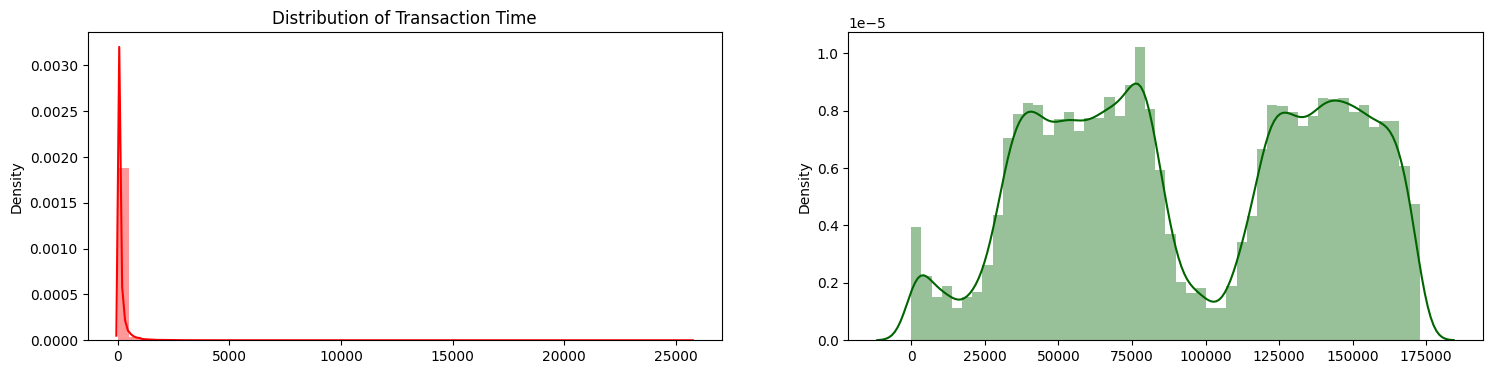

In [ ]:
fig, ax = plt.subplots(1, 2 , figsize=(18,4))

amount_val = df['Amount'].values
time_val = df['Time'].values

sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Distribution of Trasaction Amount')


sns.distplot(time_val, ax=ax[1], color='darkgreen')
ax[0].set_title('Distribution of Transaction Time')

# Monte Carlo Modeling

In [ ]:
## Scoring Function
def Scoring_Function(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0
    brier = np.mean((y_true - y_prob) ** 2)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Brier Score": brier
    }

In [ ]:
sss = StratifiedShuffleSplit(
    n_splits=100,      # number of Monte Carlo iterations
    test_size=0.33,
    random_state=67
)

In [ ]:
X = df.drop(columns=["Class"])
y = df["Class"]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
## Logistic Regression
log_scores = []
log_cm_total = np.zeros((2, 2), dtype=int)

for train_idx, test_idx in sss.split(X_scaled, y):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    log_model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=67
    )

    log_model.fit(X_train, y_train)

    y_prob = log_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    log_scores.append(Scoring_Function(y_test, y_pred, y_prob))
    log_cm_total += confusion_matrix(y_test, y_pred)

log_results = pd.DataFrame(log_scores)

print("Logistic Regression Mean Scores")
print(log_results.mean())

print("\nLogistic Regression Std Dev")
print(log_results.std())

Logistic Regression Mean Scores
Accuracy       0.977178
Precision      0.065012
Recall         0.906914
F1             0.121257
Brier Score    0.022588
dtype: float64

Logistic Regression Std Dev
Accuracy       0.002197
Precision      0.005478
Recall         0.022156
F1             0.009401
Brier Score    0.001784
dtype: float64


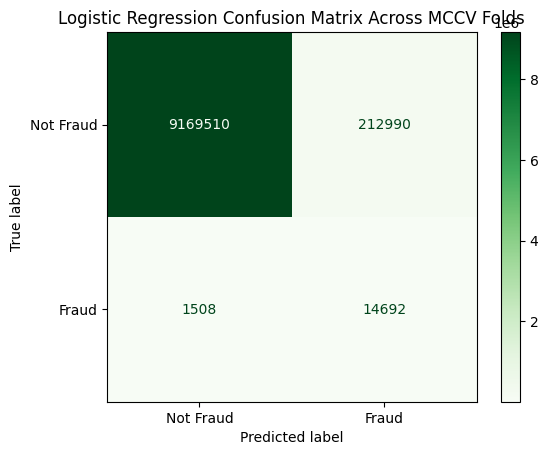

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=log_cm_total,
    display_labels=["Not Fraud", "Fraud"]
)

disp.plot(cmap="Greens", values_format="d")
plt.title("Logistic Regression Confusion Matrix Across MCCV Folds")
plt.show()

In [ ]:
## XG Boost
xgb_scores = []
xgb_cm_total = np.zeros((2, 2), dtype=int)

scale_pos_weight = (y == 0).sum() / (y == 1).sum()

for train_idx, test_idx in sss.split(X_scaled, y):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=67
    )

    xgb_model.fit(X_train, y_train)

    y_prob = xgb_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    xgb_scores.append(Scoring_Function(y_test, y_pred, y_prob))
    xgb_cm_total += confusion_matrix(y_test, y_pred)

In [ ]:
xgb_results = pd.DataFrame(xgb_scores)

print("XGBoost Mean Scores")
print(xgb_results.mean())

print("\nXGBoost Std Dev")
print(xgb_results.std())

XGBoost Mean Scores
Accuracy       0.998302
Precision      0.509827
Recall         0.857716
F1             0.637512
Brier Score    0.001741
dtype: float64

XGBoost Std Dev
Accuracy       0.000282
Precision      0.047208
Recall         0.027147
F1             0.032911
Brier Score    0.000252
dtype: float64


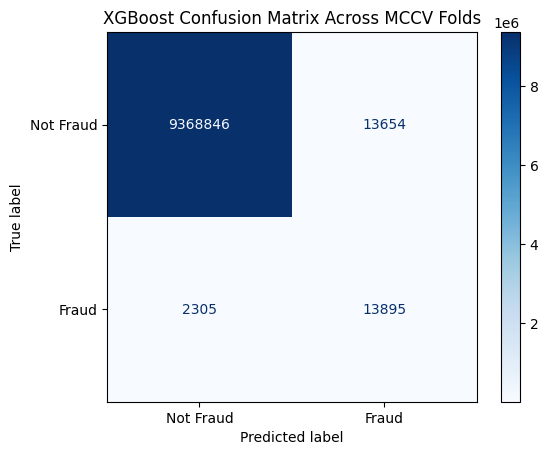

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=xgb_cm_total,
    display_labels=["Not Fraud", "Fraud"]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("XGBoost Confusion Matrix Across MCCV Folds")
plt.show()

In [ ]:
## Light GBM
lgb_scores = []
lgb_cm_total = np.zeros((2, 2), dtype=int)

for train_idx, test_idx in sss.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    lgb_model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        objective="binary",
        random_state=67,
        n_jobs=-1,
        verbose=-1
    )

    lgb_model.fit(X_train, y_train)

    y_prob = lgb_model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    lgb_scores.append(Scoring_Function(y_test, y_pred, y_prob))
    lgb_cm_total += confusion_matrix(y_test, y_pred)

In [ ]:
lgb_results = pd.DataFrame(lgb_scores)

print("LightGBM Mean Scores")
print(lgb_results.mean())

print("\nLightGBM Std Dev")
print(lgb_results.std())

LightGBM Mean Scores
Accuracy       0.999551
Precision      0.913030
Recall         0.818210
F1             0.862539
Brier Score    0.000416
dtype: float64

LightGBM Std Dev
Accuracy       0.000055
Precision      0.020419
Recall         0.031431
F1             0.018353
Brier Score    0.000053
dtype: float64


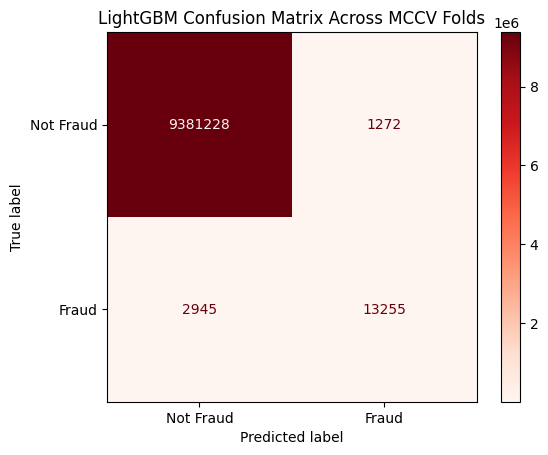

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=lgb_cm_total,
    display_labels=["Not Fraud", "Fraud"]
)

disp.plot(cmap="Reds", values_format="d")
plt.title("LightGBM Confusion Matrix Across MCCV Folds")
plt.show()

# Final Results Monte Carlo

In [ ]:
MCCV_Results_For_All_Models = {
    "LR": log_results.mean(),
    "XGB": xgb_results.mean(),
    "LGBM": lgb_results.mean(),
}

Results = []
for Model in MCCV_Results_For_All_Models:
    accuracy = MCCV_Results_For_All_Models[Model]["Accuracy"]
    precision = MCCV_Results_For_All_Models[Model]["Precision"]
    recall = MCCV_Results_For_All_Models[Model]["Recall"]
    f1 = MCCV_Results_For_All_Models[Model]["F1"]
    brier = MCCV_Results_For_All_Models[Model]["Brier Score"]

    Results.append([Model, accuracy, precision, recall, f1, brier])

print(tabulate.tabulate(
    Results,
    headers=["Model", "Accuracy", "Precision", "Recall", "F1", "Brier Score"]
))

Model      Accuracy    Precision    Recall        F1    Brier Score
-------  ----------  -----------  --------  --------  -------------
LR         0.977178    0.0650122  0.906914  0.121257    0.0225877
XGB        0.998302    0.509827   0.857716  0.637512    0.00174062
LGBM       0.999551    0.91303    0.81821   0.862539    0.000416182
